# Superstore Profit Loss Analysis
**Author:** Hadiqa Imran  
**Date:** June 2026  
**Dataset:** Superstore Sales Dataset (Kaggle)  
**Tool:** Python, Pandas, Scikit-learn, Power BI


## Business Question
__What is actually driving profit loss — and what should the business do about it?__

__Hypothesis:__ Heavy discounting is the primary driver of profit loss in this business.

## Phase 1: Exploratory Data Analysis (EDA)
Before testing our hypothesis, we first explore where losses are actually occurring — 
by category, sub-category, region, and state. 
We avoid assumptions and let the data speak first.

In [49]:
import pandas as pd
st=pd.read_csv('Superstore.csv', encoding='ISO-8859-1')
st.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [50]:
no_discount_cart = st[(st['Product Name'] == "Eldon Fold 'N Roll Cart System") & (st['Discount'] == 0)]
print(no_discount_cart)
#Let's investigate whether discount is associated with lower profitability.

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
6326    6327  CA-2011-167927  21-01-2011  27-01-2011  Standard Class   
7371    7372  US-2014-123862  08-01-2014  10-01-2014    Second Class   

     Customer ID Customer Name   Segment        Country        City  ...  \
6326    XP-21865  Xylona Preis  Consumer  United States    Westland  ...   
7371    JF-15190  Jamie Frazer  Consumer  United States  Long Beach  ...   

     Postal Code   Region       Product ID         Category Sub-Category  \
6326       48185  Central  OFF-ST-10000760  Office Supplies      Storage   
7371       90805     West  OFF-ST-10000760  Office Supplies      Storage   

                        Product Name   Sales  Quantity  Discount   Profit  
6326  Eldon Fold 'N Roll Cart System   13.98         1       0.0   4.0542  
7371  Eldon Fold 'N Roll Cart System  153.78        11       0.0  44.5962  

[2 rows x 21 columns]


In [51]:

category_analysis = st.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Profit')
print(category_analysis,"\n\n")
sub_category_analysis = st.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Profit')
print(sub_category_analysis,"\n\n")
profit_margin_ca=category_analysis['Profit']/category_analysis['Sales']
print(profit_margin_ca,"\n\n")
profit_margin_sca=sub_category_analysis['Profit']/sub_category_analysis['Sales']
print(profit_margin_sca,"\n\n")

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481 


                    Sales      Profit
Sub-Category                         
Tables        206965.5320 -17725.4811
Bookcases     114879.9963  -3472.5560
Supplies       46673.5380  -1189.0995
Fasteners       3024.2800    949.5182
Machines      189238.6310   3384.7569
Labels         12486.3120   5546.2540
Art            27118.7920   6527.7870
Envelopes      16476.4020   6964.1767
Furnishings    91705.1640  13059.1436
Appliances    107532.1610  18138.0054
Storage       223843.6080  21278.8264
Chairs        328449.1030  26590.1663
Binders       203412.7330  30221.7633
Paper          78479.2060  34053.5693
Accessories   167380.3180  41936.6357
Phones        330007.0540  44515.7306
Copiers       149528.0300  55617.8249 


Category
Furniture          0.024867
Office Supplies    0.1703

In [25]:


region_analysis = st.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Profit')
print(region_analysis,"\n\n")
state_analysis = st.groupby('State')[['Sales', 'Profit']].sum().sort_values('Profit')
print(state_analysis,"\n\n")
profit_margin_region=region_analysis['Profit']/region_analysis['Sales']
print(profit_margin_region,"\n\n")
profit_margin_state=state_analysis['Profit']/state_analysis['Sales']
print(profit_margin_state,"\n\n")

               Sales       Profit
Region                           
Central  501239.8908   39706.3625
South    391721.9050   46749.4303
East     678781.2400   91522.7800
West     725457.8245  108418.4489 


                            Sales      Profit
State                                        
Texas                 170188.0458 -25729.3563
Ohio                   78258.1360 -16971.3766
Pennsylvania          116511.9140 -15559.9603
Illinois               80166.1010 -12607.8870
North Carolina         55603.1640  -7490.9122
Colorado               32108.1180  -6527.8579
Tennessee              30661.8730  -5341.6936
Arizona                35282.0010  -3427.9246
Florida                89473.7080  -3399.3017
Oregon                 17431.1500  -1190.4705
Wyoming                 1603.1360    100.1960
West Virginia           1209.8240    185.9216
North Dakota             919.9100    230.1497
South Dakota            1315.5600    394.8283
Maine                   1270.5300    454.4862
Idaho      

In [52]:
count_of_orders=(st['Profit']>=0).value_counts().rename({True:'Profit',False:'Loss'})
print(count_of_orders)

Profit
Profit    8123
Loss      1871
Name: count, dtype: int64


In [53]:
st_sorted=st.sort_values('Profit')
st_sorted.head(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7772,7773,CA-2013-108196,26-11-2013,03-12-2013,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,43130,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
683,684,US-2014-168116,05-11-2014,05-11-2014,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,27217,South,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
9774,9775,CA-2011-169019,26-07-2011,30-07-2011,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,78207,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
3011,3012,CA-2014-134845,18-04-2014,24-04-2014,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,80027,West,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800
4991,4992,US-2014-122714,08-12-2014,14-12-2014,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,60653,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845
3151,3152,CA-2012-147830,15-12-2012,18-12-2012,First Class,NF-18385,Natalie Fritzler,Consumer,United States,Newark,...,43055,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912
5310,5311,CA-2014-131254,20-11-2014,22-11-2014,First Class,NC-18415,Nathan Cano,Consumer,United States,Houston,...,77095,Central,OFF-BI-10003527,Office Supplies,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820
9639,9640,CA-2012-116638,28-01-2012,31-01-2012,Second Class,JH-15985,Joseph Holt,Consumer,United States,Concord,...,28027,South,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124
1199,1200,CA-2013-130946,09-04-2013,13-04-2013,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,...,77041,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464
2697,2698,CA-2011-145317,18-03-2011,23-03-2011,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784


## EDA Key Findings
- **Furniture** is the worst performing category, driven by **Tables** and **Bookcases**
- **Central region** has the lowest profit margin at only **7.9%**
- **10 states** have negative total profit, led by Texas (-$25.7K), Ohio (-$17K), Pennsylvania (-$15.6K)
- Nearly **1 in 5 orders (18.72%)** is loss-making — this is systemic, not random
- Top 20 worst orders show discounts of **0.4 to 0.8** — pointing toward discounting as a key factor

## Phase 2: Discount vs Profit Analysis
We now investigate the relationship between discounting and profit directly.  
This is where we test our hypothesis using correlation analysis and visual exploration.

In [54]:
st[['Discount', 'Profit', 'Sales', 'Quantity']].corr()

,Discount,Profit,Sales,Quantity
Discount,1.000000,-0.219487,-0.028190,0.008623
Profit,-0.219487,1.000000,0.479064,0.066253
Sales,-0.028190,0.479064,1.000000,0.200795
Quantity,0.008623,0.066253,0.200795,1.000000


### Correlation Analysis Results
- **Discount vs Profit: -0.219** — negative but weak. Discounting hurts profit but is not the sole driver.
- **Sales vs Profit: +0.479** — stronger than discount. Higher revenue orders tend to be more profitable.
- **Quantity vs Profit: +0.008** — almost no relationship. Selling more units barely moves profit.

This already challenges our hypothesis — if discounting were the main villain, 
we'd expect a much stronger correlation (closer to -0.6 or -0.7).

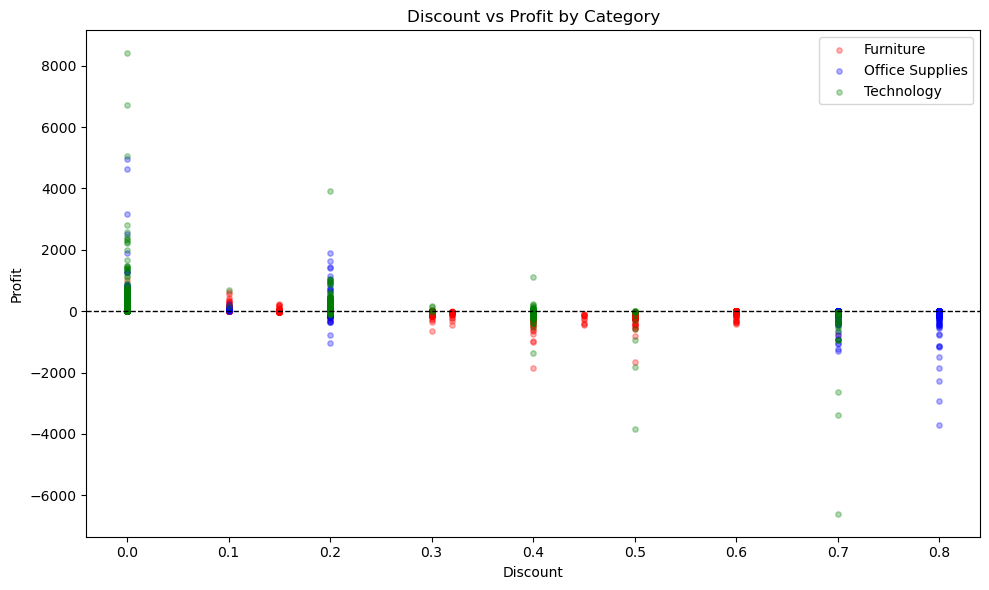

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = {'Furniture': 'red', 'Office Supplies': 'blue', 'Technology': 'green'}


plt.figure(figsize=(10, 6))

for category, group in st.groupby('Category'):
    plt.scatter(group['Discount'],     
                group['Profit'],         
                c=colors[category],      
                label=category,         
                alpha=0.3,               
                s=15)                    

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit by Category')
plt.legend()
plt.tight_layout()
plt.show()

### Scatter Plot Observations
- Below **20% discount**: most orders are profitable across all categories
- Above **30% discount**: orders consistently fall below the break-even line
- **Furniture** shows losses even at moderate discounts — suggesting a structural margin problem
- **Technology** shows some losses even at 0% discount — some products are loss-making at full price

In [56]:
st['Discount_Bucket'] = pd.cut(st['Discount'], bins=[0, 0.01, 0.2, 0.4, 0.6, 0.8, 1.0],
                                labels=['0%','1-20%','20-40%','40-60%','60-80%','80%+'],
                                include_lowest=True)
print(st.groupby('Discount_Bucket', observed=False)['Profit'].mean())

Discount_Bucket
0%         66.900292
1-20%      26.501571
20-40%    -77.864055
40-60%   -134.624160
60-80%    -98.348741
80%+             NaN
Name: Profit, dtype: float64


### Discount Bucket Analysis — The Cliff
| Discount Bucket | Average Profit |
|----------------|---------------|
| 0% | +$66.90 |
| 1-20% | +$26.50 |
| 20-40% | -$77.86 |
| 40-60% | -$134.62 |
| 60-80% | -$98.35 |

**Key insight:** The break-even cliff is precisely at 20%.  
Below 20% the business makes money. Above 20% it consistently loses money.  
This is a clear, actionable policy threshold.

## Phase 3: Linear Regression — Quantifying What Drives Profit
Correlation tells us two variables are related. Regression tells us *how much* each variable 
contributes to profit when controlling for everything else simultaneously.

We use Linear Regression with the following features:
- Sales, Quantity, Discount (numeric)
- Category, Sub-Category, Region, Segment (encoded as dummy variables)

**Target variable:** Profit

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

# Select features and target
features = ['Sales', 'Quantity', 'Discount', 'Category', 'Sub-Category', 'Region', 'Segment']
target = 'Profit'
model_df = pd.get_dummies(st[features + [target]], drop_first=True)

X = model_df.drop(columns=[target])
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X.shape)
print(X.columns.tolist())

(9994, 26)
['Sales', 'Quantity', 'Discount', 'Category_Office Supplies', 'Category_Technology', 'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Envelopes', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings', 'Sub-Category_Labels', 'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones', 'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables', 'Region_East', 'Region_South', 'Region_West', 'Segment_Corporate', 'Segment_Home Office']


In [58]:
print(y.describe())
print("\nOutliers above 99th percentile:", (y > y.quantile(0.99)).sum())
print("Outliers below 1st percentile:", (y < y.quantile(0.01)).sum())

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

Outliers above 99th percentile: 100
Outliers below 1st percentile: 100


In [59]:
lower = y.quantile(0.01)
upper = y.quantile(0.99)

model_df_clean = model_df.copy()
model_df_clean[target] = model_df_clean[target].clip(lower, upper)

X_clean = model_df_clean.drop(columns=[target])
y_clean = model_df_clean[target]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
print("R² Score:", round(r2_score(y_test2, y_pred2), 4))
print("MAE:", round(mean_absolute_error(y_test2, y_pred2), 2))

R² Score: 0.1903
MAE: 42.29


### Model Performance
- **R² Score: 0.19** — the model explains 19% of profit variation
- **MAE: $42.29** — predictions are off by $42 on average

Note: The initial model returned R² = -0.644 due to extreme outliers (+$8,399 to -$6,599).  
After winsorizing at the 1st and 99th percentile, performance improved significantly.  
R² of 0.19 is acceptable given the dataset lacks cost, shipping, and return data 
which directly affect profit but are not present here.

In [60]:
coef_df = pd.DataFrame({
    'Feature': X_clean.columns,
    'Coefficient': model2.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string())

                     Feature  Coefficient
10      Sub-Category_Copiers   143.505152
7       Sub-Category_Binders    44.838152
4        Category_Technology    30.173792
5    Sub-Category_Appliances    25.267743
9        Sub-Category_Chairs    15.904119
13  Sub-Category_Furnishings    14.009910
3   Category_Office Supplies    10.650794
11    Sub-Category_Envelopes     7.107664
16        Sub-Category_Paper     4.691278
25       Segment_Home Office     2.346364
1                   Quantity     2.221371
24         Segment_Corporate     0.622007
0                      Sales     0.079309
17       Sub-Category_Phones    -2.145547
22              Region_South    -2.960964
14       Sub-Category_Labels    -5.264394
21               Region_East    -7.566195
23               Region_West    -9.860291
6           Sub-Category_Art   -10.484332
12    Sub-Category_Fasteners   -12.488184
18      Sub-Category_Storage   -13.654746
15     Sub-Category_Machines   -19.741352
8     Sub-Category_Bookcases   -24

### Regression Coefficients — What Actually Drives Profit?

| Feature | Coefficient | Interpretation |
|---------|------------|----------------|
| Discount | **-191.03** | Strongest negative driver — each 10% discount costs ~$19 profit |
| Sub-Category: Tables | -46.62 | Loss-making even after controlling for discount |
| Sub-Category: Supplies | -29.36 | Structurally weak margins |
| Sub-Category: Bookcases | -24.12 | Loss-making independent of discounting |
| Sub-Category: Copiers | +143.51 | Single strongest profit driver in the business |
| Category: Technology | +30.17 | Strong positive category overall |

**Key insight:** Discount is confirmed as the dominant negative driver.  
However, Tables and Bookcases show large negative coefficients *after* controlling for discount —  
meaning they lose money structurally, not just because of discounting.

## Conclusion & Recommendations

### Hypothesis Evaluation
**Hypothesis:** Heavy discounting is the primary driver of profit loss.  
**Verdict: Partially Supported**

Discounting is the single strongest predictor of profit loss (coefficient: -191).  
However, Tables and Bookcases are loss-making even without heavy discounts,  
and regional factors contribute independently. Reducing discounts alone will not eliminate all losses.

### Recommendations
| Finding | Recommendation | Evidence |
|---------|---------------|----------|
| Discounts above 20% destroy profit | Cap discounts at 20% company-wide | 40-60% bucket has ~100% loss rate |
| Tables & Bookcases structurally loss-making | Review supplier costs or discontinue | Negative profit even without heavy discounting |
| 19% of orders lose money | Audit discount approval process | Systemic, not random |
| Central region margin only 7.9% | Investigate regional pricing | West margin is 14.9% |
| Copiers are highest profit driver | Prioritize copier sales | Regression coefficient +143 |